In [1]:
!pip install -q -U langgraph langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.0/256.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.3 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [4]:
from langchain_groq import ChatGroq

llm=ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=GROQ_API_KEY
)

In [5]:
#subgraph state

from typing import TypedDict

class OrderState(TypedDict):
    user_query:str
    order_id:str
    order_status:str
    response:str

In [6]:
#order dataset for finding orders by agent
orders = {
    "12345": "Shipped",
    "12346": "Delivered",
    "12347": "Processing",
    "12348": "Cancelled"
}

In [7]:
def extract_order_id(state:OrderState):
    query=state['user_query']
    prompt = f"""
    Extract the order ID from this customer message.

    Customer message:
    {query}

    Return ONLY the order ID.
    If there is no order ID, return NONE.
    """

    result=llm.invoke(prompt)

    order_id=result.content.strip()

    return {
        'order_id':order_id
    }


In [8]:
#find order id from the database
def get_order_status(state:OrderState):
    order_id=state['order_id']
    status=orders.get(order_id,"Order not Found")

    return{
        "order_status":status
    }

In [9]:
def generate_order_response(state:OrderState):
    query=state['user_query']
    order_id=state['order_id']
    status=state['order_status']

    prompt = f"""
    You are a helpful customer support agent.

    Customer:
    {query}

    Order ID:
    {order_id}

    Order Status:
    {status}

    Give a short and polite response to the customer.
    """

    result=llm.invoke(prompt)
    return {
        'response':result.content
    }



#Build Subgraph

In [10]:
from langgraph.graph import StateGraph,START,END

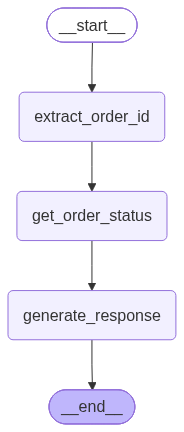

In [11]:
order_builder=StateGraph(OrderState)

order_builder.add_node("extract_order_id",extract_order_id)
order_builder.add_node("get_order_status",get_order_status)
order_builder.add_node("generate_response",generate_order_response)


order_builder.add_edge(START,'extract_order_id')
order_builder.add_edge('extract_order_id','get_order_status')
order_builder.add_edge('get_order_status','generate_response')
order_builder.add_edge('generate_response',END)

order_subgraph=order_builder.compile()
order_subgraph

##test subgraph

In [12]:
result = order_subgraph.invoke({
    "user_query": "My order is delayed. Order ID is 12345."
})

print(result)

{'user_query': 'My order is delayed. Order ID is 12345.', 'order_id': '12345', 'order_status': 'Shipped', 'response': 'I’m sorry for any inconvenience. Your order (12345) has shipped and is on its way. It should arrive within the next few days. If you need a more specific delivery estimate or have any other questions, just let me know!'}


In [13]:
result

{'user_query': 'My order is delayed. Order ID is 12345.',
 'order_id': '12345',
 'order_status': 'Shipped',
 'response': 'I’m sorry for any inconvenience. Your order (12345) has shipped and is on its way. It should arrive within the next few days. If you need a more specific delivery estimate or have any other questions, just let me know!'}

# Main Graph

In [24]:
##  main state

class MainState(TypedDict):
    user_query:str
    response:str
    route:str

In [25]:
#this node decide ,what does user actually want

def router(state:MainState):
    query=state['user_query']
    prompt = f"""
    Classify this customer query.

    Query:
    {query}

    If it is about an order, return:
    ORDER

    Otherwise return:
    GENERAL

    Return ONLY one word.
    """
    result=llm.invoke(prompt)
    return{
        "route":result.content.strip().upper()
    }


In [26]:
#conditional node
def decide_route(state:MainState):
    if "ORDER" in state['route']:
        return "order"
    return 'general'

In [27]:
def general_response(state:MainState):
    result = llm.invoke(
        f"""
        Answer this customer question politely:

        {state["user_query"]}
        """
    )

    return {
        "response": result.content
    }


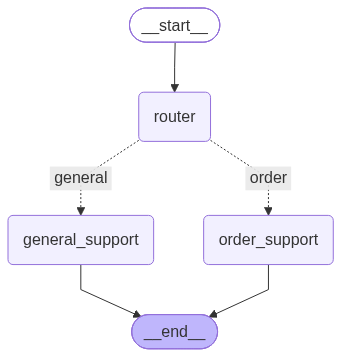

In [28]:
main_builder=StateGraph(MainState)

main_builder.add_node("router",router)
main_builder.add_node('order_support',order_subgraph)
main_builder.add_node('general_support',general_response)

main_builder.add_edge(START,'router')
main_builder.add_conditional_edges('router',decide_route,{
    'order':'order_support',
    'general':'general_support'
})
main_builder.add_edge('order_support',END)
main_builder.add_edge('general_support',END)

main_graph=main_builder.compile()
main_graph

In [29]:
result=main_graph.invoke(
    {
        'user_query':'My order id is delayed.Order ID is 12345'
    }
)

In [30]:
result

{'user_query': 'My order id is delayed.Order ID is 12345',
 'response': 'Hi there! I see your order (ID\u202f12345) was shipped, but it appears to be delayed. I’m on it—please allow a few more days for delivery, and I’ll keep you updated. Thank you for your patience!',
 'route': 'ORDER'}

In [31]:
result=main_graph.invoke(
    {
        'user_query':'My order id is delayed.Order ID is 12347'
    }
)

In [32]:
result

{'user_query': 'My order id is delayed.Order ID is 12347',
 'response': 'I’m sorry to hear your order hasn’t arrived yet. Your order (12347) is currently in the “Processing” stage, and we’re working to get it shipped as quickly as possible. I’ll keep an eye on it and let you know as soon as it’s on its way. Thank you for your patience!',
 'route': 'ORDER'}

In [33]:
#for incorrect order id
result=main_graph.invoke(
    {
        'user_query':'My order id is delayed.Order ID is 99999'
    }
)

In [34]:
result

{'user_query': 'My order id is delayed.Order ID is 99999',
 'response': 'I’m sorry, but I can’t find order\u202f99999 in our system. Could you double‑check the ID? If it’s correct, let me know and I’ll investigate further for you.',
 'route': 'ORDER'}

In [37]:
#general support
result=main_graph.invoke(
    {
        'user_query':'hi,Tell me about your service policy'
    }
)

In [38]:
result

{'user_query': 'hi,Tell me about your service policy',
 'response': 'Hello! Thank you for reaching out. I’m happy to give you an overview of our service policy so you know exactly what to expect when you work with us.\n\n---\n\n### 1. **Service Availability**\n- **Business Hours:** Monday\u202f–\u202fFriday, 8\u202fa.m.\u202f–\u202f6\u202fp.m. (local time).  \n- **Extended Support:** We offer 24/7 emergency support for critical issues (e.g., system downtime, security incidents).  \n- **Holiday Schedule:** Our team observes all major public holidays; you’ll see a notice on our website or in your account dashboard if any services are affected.\n\n### 2. **Response & Resolution Times**\n- **Standard Inquiries:** We aim to acknowledge all tickets within **1\u202fhour** during business hours and resolve them within **24\u202fhours**.  \n- **Priority/High‑Impact Issues:** These receive a **30‑minute** acknowledgment and are resolved as quickly as possible, typically within **4\u202fhours**. 